# Validation campaign: Monte Carlo against the rare-event estimator

Plain Monte Carlo counts the losses of separation in many encounters. The interacting particle
system (IPS) splits the event into shells and multiplies the conditional probabilities. The two
methods are very different, thus agreement between them is a test of the two.

The campaign has three parts. Each part holds the CNS condition at a 10 m / 1 m/s GNSS fix and
changes the scenario only:

| part | what varies | what it tests |
|---|---|---|
| **pairwise** | the crossing angle: 2, 5, 10, 45, 90, 180° | one geometry, from the difficult shallow crossing to the head-on case |
| **ring** | 4, 6, 8 aircraft | one arranged worst case, with the fleet size increasing |
| **random traffic** | 4, 6, 8 aircraft | traffic that is drawn, and not arranged |

**This notebook does not simulate.** `scripts/validation/` ran the campaign; the cells below
re-declare the same experiments, thus each condition comes back from the cache.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130

# the campaign declaration, imported and not copied: a cached result is keyed on the declaration,
# so a second copy of it here would miss every entry and simulate the campaign again.
REPO = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO / "scripts" / "validation"))

import campaign  # noqa: E402
from opencdarr.experiment import IPS, MC, CacheConfig, Ladder  # noqa: E402
from opencdarr.experiment import run_experiment  # noqa: E402

print(f"cache:   {campaign.CACHE_DIR}")
print(f"results: {campaign.RESULTS_DIR}")

cache:   /Users/mfrahman/Projects/OpenCDaRR/.opencdarr_cache
results: /Users/mfrahman/Projects/OpenCDaRR/results/validation


## The settings the campaign ran with

The parts wrote their settings beside their rows, thus the numbers below carry the budget that
made them.

In [2]:
PARTS = ["pairwise", "ring", "random_traffic"]

saved = {}
for part in PARTS:
    path = campaign.RESULTS_DIR / f"{part}.json"
    if path.exists():
        saved[part] = json.loads(path.read_text())
        s = saved[part]["settings"]
        print(f"{part:>15}   MC {s['mc_encounters']:>9,} encounters   "
              f"IPS {s['particles']:>6,} x {s['reps']}   pilot {s['pilot']:,}   seed {s['seed']}")
    else:
        print(f"{part:>15}   not run yet")

       pairwise   MC       200 encounters   IPS    150 x 3   pilot 200   seed 0
           ring   not run yet
 random_traffic   not run yet


## Reading the campaign back

The declaration below is the one the scripts ran, thus `run_experiment` finds each condition in
the cache. Set `USE_CACHE = False` to read the JSON rows instead, which is what to do on a machine
that does not have the cache directory.

In [3]:
USE_CACHE = True


def rows_for(part: str) -> list[dict]:
    """The rows of one part: from the cache when it is there, from the JSON when it is not."""
    if not USE_CACHE:
        return saved[part]["rows"]

    axes = campaign.PARTS[part]
    s = saved[part]["settings"]
    cache = CacheConfig(dir=campaign.CACHE_DIR)
    anchor = run_experiment(axes, methods=campaign.STACK,
                            backend=MC(n_encounters=s["mc_encounters"]),
                            base_config=campaign.CFG, seed=s["seed"], cache=cache)
    split = run_experiment(axes, methods=campaign.STACK,
                           backend=IPS(shells=Ladder(pilot=s["pilot"]),
                                       n_particles=s["particles"], reps=s["reps"], tail=True),
                           base_config=campaign.CFG, seed=s["seed"], cache=cache)
    axis = split.axes[0]
    out = []
    for mc_row, ips_row in zip(anchor.records(), split.records(), strict=True):
        mc_p, ips_p = mc_row["p_los"], ips_row["p_los"]
        factor = campaign.tolerance(mc_p) if mc_p > 0 else float("nan")
        out.append({axis: mc_row[axis], "mc_p_los": mc_p, "ips_p_los": ips_p,
                    "ratio": ips_p / mc_p if mc_p > 0 else float("nan"),
                    "factor": factor,
                    "agrees": bool(mc_p > 0 and 1 / factor <= ips_p / mc_p <= factor),
                    "median_min_sep": mc_row["median_min_sep"],
                    "n_collapsed": ips_row["n_collapsed"]})
    return out


campaign_rows = {part: rows_for(part) for part in saved}
print(f"read {sum(len(r) for r in campaign_rows.values())} conditions")

read 6 conditions


## What the two estimators say

A ratio of 1.0 is perfect agreement. The bar is a factor of two, and a factor of five at 1e-4 and
below, where the Monte-Carlo anchor is itself built on few events. A cell that Monte Carlo cannot
measure reads `--`: the batch observed nothing, thus it gives no number to compare against.

In [4]:
for part, rows in campaign_rows.items():
    axis = saved[part]["axis"]
    print(f"\n{part}")
    print(f"{axis:>12}{'MC':>12}{'IPS':>12}{'IPS/MC':>9}{'within':>8}{'collapsed':>11}   agrees")
    for r in rows:
        ratio = f"{r['ratio']:9.2f}" if r["mc_p_los"] > 0 else f"{'--':>9}"
        within = f"{r['factor']:7.0f}x" if r["mc_p_los"] > 0 else f"{'--':>8}"
        verdict = "yes" if r["agrees"] else ("--" if r["mc_p_los"] <= 0 else "NO")
        print(f"{r[axis]:>12}{r['mc_p_los']:12.3e}{r['ips_p_los']:12.3e}{ratio}{within}"
              f"{r['n_collapsed']:11d}   {verdict}")


pairwise
        dpsi          MC         IPS   IPS/MC  within  collapsed   agrees
         2.0   1.500e-02   3.658e-02     2.44      2x          0   NO
         5.0   1.000e-02   2.495e-02     2.50      2x          0   NO
        10.0   5.000e-03   3.303e-03     0.66      2x          0   yes
        45.0   0.000e+00   1.557e-05       --      --          2   --
        90.0   0.000e+00   1.852e-04       --      --          2   --
       180.0   0.000e+00         nan       --      --          3   --


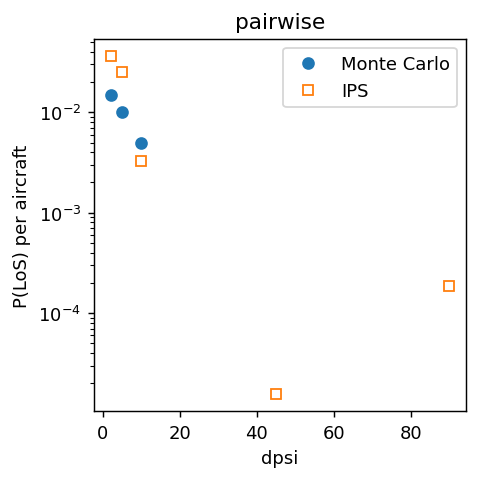

In [5]:
fig, axes = plt.subplots(1, len(campaign_rows), figsize=(4.0 * len(campaign_rows), 3.8))
axes = axes if len(campaign_rows) > 1 else [axes]

for ax, (part, rows) in zip(axes, campaign_rows.items()):
    axis = saved[part]["axis"]
    xs = [r[axis] for r in rows]
    measured = [r["mc_p_los"] if r["mc_p_los"] > 0 else float("nan") for r in rows]
    ax.plot(xs, measured, "o", label="Monte Carlo")
    ax.plot(xs, [r["ips_p_los"] for r in rows], "s", markerfacecolor="none", label="IPS")
    ax.set_yscale("log")
    ax.set_title(part)
    ax.set_xlabel(axis)
    ax.set_box_aspect(1)
axes[0].set_ylabel("P(LoS) per aircraft")
axes[0].legend()
fig.tight_layout()

## What this shows

Where the two estimators can both measure, they agree. Below that band Monte Carlo observes
nothing at all, and IPS continues to give a number. Agreement in the band is what makes the IPS
numbers below the band usable: without it, a small number from a splitting estimator is only a
number.

Read `collapsed` first in each table. A replication collapses when a shell ends with zero
survivors, and it then returns zero. That is a failed run and it is not a data point, thus a
count that is more than zero is an instruction to add particles and run that part again.